## 0. Download dataset
**Note:** If you can't download using gdown due to limited number of downloads, please download it manually and upload it to your drive, then copy it from the drive to colab.
```python
from google.colab import drive

drive.mount('/content/drive')
!cp /path/to/dataset/on/your/drive .
```

In [23]:
!gdown --id 178YSDYmlRh54IcxStgYA3UyKFRM9-3DO

/usr/local/lib/python3.10/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=178YSDYmlRh54IcxStgYA3UyKFRM9-3DO
To: /content/dataset.zip
100% 2.35M/2.35M [00:00<00:00, 54.9MB/s]


In [24]:
!unzip dataset.zip

Archive:  dataset.zip
replace dataset/weatherHistory.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: n


In [25]:
!pip install unidecode

## 1. Import libraries

In [26]:
import torch
import torch.nn as nn

seed = 1
torch.manual_seed(seed)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from torch.utils.data import Dataset, DataLoader

## 2. Read dataset

In [27]:
dataset_filepath = 'dataset/weatherHistory.csv'
df = pd.read_csv(dataset_filepath)

In [28]:
univariate_df = df['Temperature (C)']
univariate_df.index = df['Formatted Date']

In [29]:
univariate_df

,Temperature (C)
Formatted Date,
2006-04-01 00:00:00.000 +0200,9.472222
2006-04-01 01:00:00.000 +0200,9.355556
2006-04-01 02:00:00.000 +0200,9.377778
2006-04-01 03:00:00.000 +0200,8.288889
2006-04-01 04:00:00.000 +0200,8.755556
...,...
2016-09-09 19:00:00.000 +0200,26.016667
2016-09-09 20:00:00.000 +0200,24.583333
2016-09-09 21:00:00.000 +0200,22.038889


## 3. Data preprocessing

In [30]:
input_size = 6
label_size = 1
offset = 1

def slicing_window(df, df_start_idx, df_end_idx, input_size, label_size, offset):
    features = []
    labels = []

    window_size = input_size + offset

    if df_end_idx == None:
        df_end_idx = len(df) - window_size

    for idx in range(df_start_idx, df_end_idx):
        feature_end_idx = idx + input_size
        label_start_idx = idx + window_size - label_size

        feature = df[idx:feature_end_idx]
        label = df[label_start_idx:(idx+window_size)]

        features.append(feature)
        labels.append(label)

    features = np.expand_dims(np.array(features), -1)
    labels = np.array(labels)

    return features, labels

## 4. Train, val, test split

In [31]:
dataset_length = len(univariate_df)
train_size = 0.7
val_size = 0.2
train_end_idx = int(train_size * dataset_length)
val_end_idx = int(val_size * dataset_length) + train_end_idx

X_train, y_train = slicing_window(
    univariate_df,
    df_start_idx=0,
    df_end_idx=train_end_idx,
    input_size=input_size,
    label_size=label_size,
    offset=offset
)

X_val, y_val = slicing_window(
    univariate_df,
    df_start_idx=train_end_idx,
    df_end_idx=val_end_idx,
    input_size=input_size,
    label_size=label_size,
    offset=offset
)

X_test, y_test = slicing_window(
    univariate_df,
    df_start_idx=val_end_idx,
    df_end_idx=None,
    input_size=input_size,
    label_size=label_size,
    offset=offset
)

## 5. Implement PyTorch dataset

In [32]:
class WeatherForecast(Dataset):
    def __init__(
        self,
        X, y,
        transform=None
    ):
        self.X = X
        self.y = y
        self.transform = transform

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        X = self.X[idx]
        y = self.y[idx]

        if self.transform:
            X = self.transform(X)

        X = torch.tensor(X, dtype=torch.float32)
        y = torch.tensor(y, dtype=torch.float32)

        return X, y

## 6. Create dataloader

In [33]:
train_dataset = WeatherForecast(
    X_train, y_train
)
val_dataset = WeatherForecast(
    X_val, y_val
)
test_dataset = WeatherForecast(
    X_test, y_test
)

In [34]:
train_batch_size = 128
test_batch_size = 8

train_loader = DataLoader(
    train_dataset,
    batch_size=train_batch_size,
    shuffle=True
)
val_loader = DataLoader(
    val_dataset,
    batch_size=test_batch_size,
    shuffle=False
)
test_loader = DataLoader(
    test_dataset,
    batch_size=test_batch_size,
    shuffle=False
)

## 7. Implement model

In [42]:
class WeatherForecastor(nn.Module):
    def __init__(
        self, embedding_dim, hidden_size,
        n_layers, dropout_prob,
        use_lstm=False, bidirectional=False
    ):
        super(WeatherForecastor, self).__init__()
        if use_lstm:
            self.rnn = nn.LSTM(
                embedding_dim, hidden_size,
                n_layers, batch_first=True,
                bidirectional=bidirectional
            )
        else:
          self.rnn = nn.RNN(
              embedding_dim, hidden_size,
              n_layers, batch_first=True
          )
        self.norm = nn.LayerNorm(hidden_size * (2 if bidirectional else 1))

        self.dropout = nn.Dropout(dropout_prob)
        self.fc = nn.Linear(hidden_size  * (2 if bidirectional else 1), 1)

    def forward(self, x):
        x, hn = self.rnn(x)
        x = x[:, -1, :]
        x = self.norm(x)
        x = self.dropout(x)
        x = self.fc(x)

        return x

In [43]:
embedding_dim = 1
hidden_size = 8
n_layers = 3
dropout_prob = 0.2
device = 'cuda' if torch.cuda.is_available() else 'cpu'

model = WeatherForecastor(
    embedding_dim=embedding_dim,
    hidden_size=hidden_size,
    n_layers=n_layers,
    dropout_prob=dropout_prob
).to(device)

model_lstm = WeatherForecastor(
    embedding_dim=embedding_dim,
    hidden_size=hidden_size,
    n_layers=n_layers,
    dropout_prob=dropout_prob,
    use_lstm=True
).to(device)

model_bilstm = WeatherForecastor(
    embedding_dim=embedding_dim,
    hidden_size=hidden_size,
    n_layers=n_layers,
    dropout_prob=dropout_prob,
    use_lstm=True,
    bidirectional=True
).to(device)

In [44]:
model.eval()
model_lstm.eval()
model_bilstm.eval()

dummy_tensor = torch.randn((1, 6, 1)).to(device)

with torch.no_grad():
    output_1 = model(dummy_tensor)
    output_2 = model_lstm(dummy_tensor)
    output_3 = model_bilstm(dummy_tensor)

print('Output rrn shape:', output_1.shape)
print('Output lstm shape:', output_2.shape)
print('Output bilstm shape:', output_3.shape)

Output rrn shape: torch.Size([1, 1])
Output lstm shape: torch.Size([1, 1])
Output bilstm shape: torch.Size([1, 1])


## 8. Training

In [45]:
def evaluate(model, dataloader, criterion, device):
    model.eval()

    losses = []
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            losses.append(loss.item())

    loss = sum(losses) / len(losses)

    return loss

In [46]:
def fit(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    device,
    epochs
):
    train_losses = []
    val_losses = []

    for epoch in range(epochs):
        batch_train_losses = []

        model.train()
        for idx, (inputs, labels) in enumerate(train_loader):
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            batch_train_losses.append(loss.item())

        train_loss = sum(batch_train_losses) / len(batch_train_losses)
        train_losses.append(train_loss)

        val_loss = evaluate(
            model, val_loader,
            criterion, device
        )
        val_losses.append(val_loss)

        print(f'EPOCH {epoch + 1}:\tTrain loss: {train_loss:.4f}\tVal loss: {val_loss:.4f}')

    return train_losses, val_losses

In [53]:
lr = 1e-3
epochs = 50

criterion = nn.MSELoss()
optimizer_rnn = torch.optim.Adam(
    model.parameters(),
    lr=lr
)
optimizer_lstm = torch.optim.Adam(
    model_lstm.parameters(),
    lr=lr
)
optimizer_bilstm = torch.optim.Adam(
    model_bilstm.parameters(),
    lr=lr
)

In [48]:
train_losses_1, val_losses_1 = fit(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer_rnn,
    device,
    epochs
)

EPOCH 1:	Train loss: 133.8146	Val loss: 44.9773
EPOCH 2:	Train loss: 29.8890	Val loss: 7.0657
EPOCH 3:	Train loss: 14.8759	Val loss: 3.3202
EPOCH 4:	Train loss: 12.0935	Val loss: 2.2078
EPOCH 5:	Train loss: 10.5051	Val loss: 2.0830
EPOCH 6:	Train loss: 9.9918	Val loss: 2.1135
EPOCH 7:	Train loss: 9.4262	Val loss: 2.0820
EPOCH 8:	Train loss: 9.2905	Val loss: 1.8189
EPOCH 9:	Train loss: 8.9414	Val loss: 1.5499
EPOCH 10:	Train loss: 8.7643	Val loss: 1.6652
EPOCH 11:	Train loss: 8.6295	Val loss: 2.1121
EPOCH 12:	Train loss: 8.4108	Val loss: 2.1329
EPOCH 13:	Train loss: 8.2890	Val loss: 1.6565
EPOCH 14:	Train loss: 8.1245	Val loss: 1.6451
EPOCH 15:	Train loss: 7.8160	Val loss: 1.6881
EPOCH 16:	Train loss: 7.8018	Val loss: 1.6484
EPOCH 17:	Train loss: 7.5309	Val loss: 1.7572
EPOCH 18:	Train loss: 7.3857	Val loss: 1.6918
EPOCH 19:	Train loss: 7.2902	Val loss: 1.6064
EPOCH 20:	Train loss: 7.0700	Val loss: 1.6707
EPOCH 21:	Train loss: 7.0185	Val loss: 1.5074
EPOCH 22:	Train loss: 6.7841	Val los

In [54]:
train_losses_2, val_losses_2 = fit(
    model_lstm,
    train_loader,
    val_loader,
    criterion,
    optimizer_lstm,
    device,
    epochs
)

EPOCH 1:	Train loss: 127.5256	Val loss: 40.6039
EPOCH 2:	Train loss: 28.2488	Val loss: 6.6360
EPOCH 3:	Train loss: 13.6690	Val loss: 2.8555
EPOCH 4:	Train loss: 11.0834	Val loss: 2.2395
EPOCH 5:	Train loss: 10.2080	Val loss: 2.3393
EPOCH 6:	Train loss: 9.8408	Val loss: 1.7182
EPOCH 7:	Train loss: 9.4976	Val loss: 1.9341
EPOCH 8:	Train loss: 9.3648	Val loss: 1.5271
EPOCH 9:	Train loss: 9.0183	Val loss: 1.6587
EPOCH 10:	Train loss: 8.9321	Val loss: 1.4715
EPOCH 11:	Train loss: 8.7081	Val loss: 2.0661
EPOCH 12:	Train loss: 8.4348	Val loss: 1.6135
EPOCH 13:	Train loss: 8.4122	Val loss: 1.6654
EPOCH 14:	Train loss: 8.1495	Val loss: 1.5730
EPOCH 15:	Train loss: 7.8679	Val loss: 1.5593
EPOCH 16:	Train loss: 7.7038	Val loss: 2.1130
EPOCH 17:	Train loss: 7.6036	Val loss: 1.5530
EPOCH 18:	Train loss: 7.5061	Val loss: 1.4794
EPOCH 19:	Train loss: 7.3341	Val loss: 1.4943
EPOCH 20:	Train loss: 7.2017	Val loss: 1.4876
EPOCH 21:	Train loss: 6.9014	Val loss: 1.5690
EPOCH 22:	Train loss: 6.9395	Val los

In [55]:
train_losses_3, val_losses_3 = fit(
    model_bilstm,
    train_loader,
    val_loader,
    criterion,
    optimizer_bilstm,
    device,
    epochs
)

EPOCH 1:	Train loss: 88.2855	Val loss: 14.5788
EPOCH 2:	Train loss: 12.7542	Val loss: 3.1686
EPOCH 3:	Train loss: 7.3149	Val loss: 2.1013
EPOCH 4:	Train loss: 6.3944	Val loss: 1.6738
EPOCH 5:	Train loss: 6.1291	Val loss: 1.7797
EPOCH 6:	Train loss: 5.9504	Val loss: 1.5918
EPOCH 7:	Train loss: 5.8203	Val loss: 1.6010
EPOCH 8:	Train loss: 5.7609	Val loss: 1.7652
EPOCH 9:	Train loss: 5.7075	Val loss: 1.6401
EPOCH 10:	Train loss: 5.6293	Val loss: 1.6112
EPOCH 11:	Train loss: 5.6178	Val loss: 1.5132
EPOCH 12:	Train loss: 5.5037	Val loss: 1.4947
EPOCH 13:	Train loss: 5.3921	Val loss: 1.7362
EPOCH 14:	Train loss: 5.2787	Val loss: 1.4577
EPOCH 15:	Train loss: 5.2398	Val loss: 1.6783
EPOCH 16:	Train loss: 5.0495	Val loss: 1.5430
EPOCH 17:	Train loss: 5.1053	Val loss: 1.4860
EPOCH 18:	Train loss: 4.9836	Val loss: 1.6910
EPOCH 19:	Train loss: 4.8886	Val loss: 1.4952
EPOCH 20:	Train loss: 4.8260	Val loss: 1.5165
EPOCH 21:	Train loss: 4.7596	Val loss: 1.8234
EPOCH 22:	Train loss: 4.7567	Val loss: 1

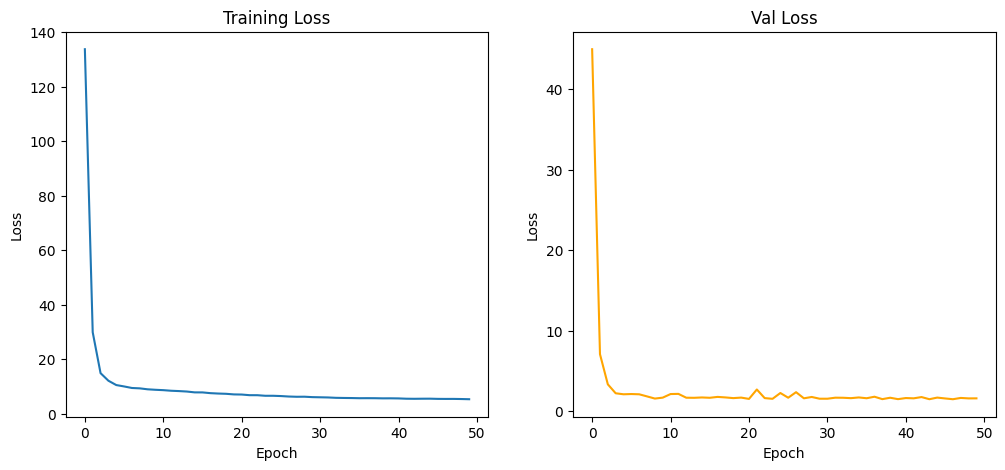

In [56]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].plot(train_losses_1)
ax[0].set_title('Training Loss')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Loss')
ax[1].plot(val_losses_1, color='orange')
ax[1].set_title('Val Loss')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('Loss')
plt.show()

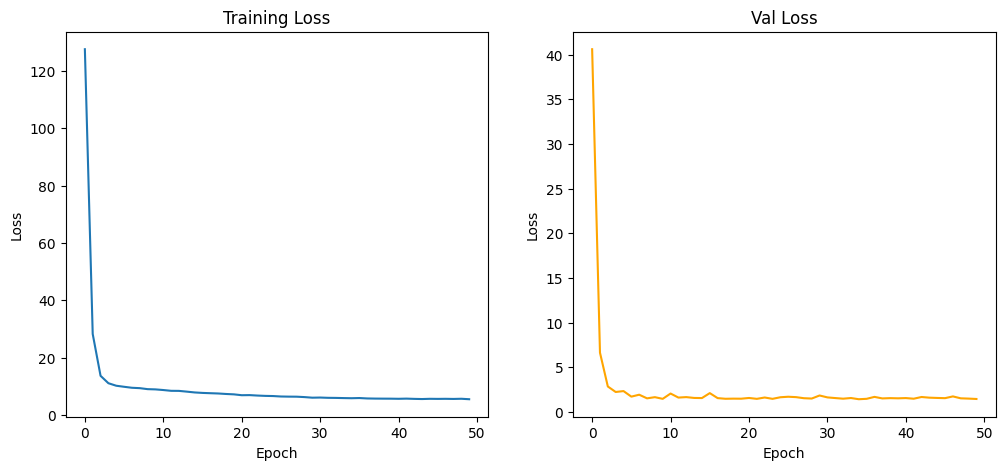

In [57]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].plot(train_losses_2)
ax[0].set_title('Training Loss')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Loss')
ax[1].plot(val_losses_2, color='orange')
ax[1].set_title('Val Loss')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('Loss')
plt.show()

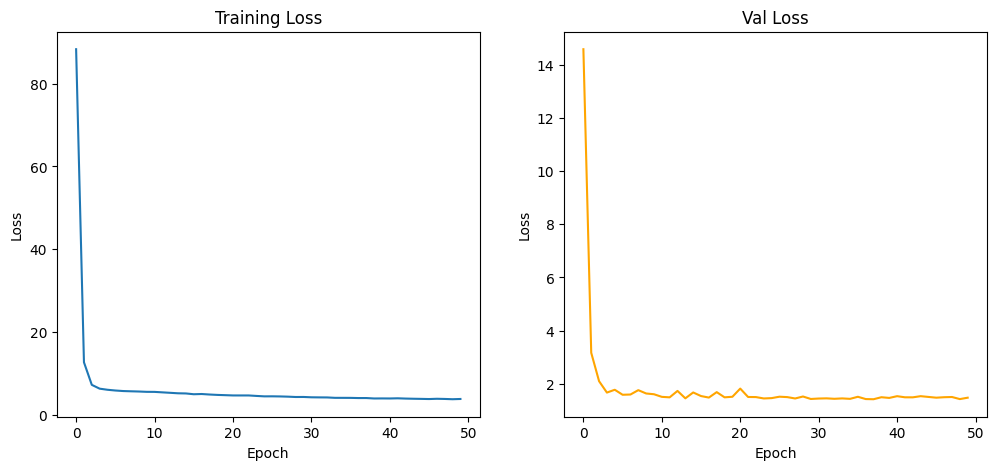

In [58]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].plot(train_losses_3)
ax[0].set_title('Training Loss')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Loss')
ax[1].plot(val_losses_3, color='orange')
ax[1].set_title('Val Loss')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('Loss')
plt.show()

## 9. Evaluation

In [59]:
val_loss = evaluate(
    model,
    val_loader,
    criterion,
    device
)
test_loss = evaluate(
    model,
    test_loader,
    criterion,
    device
)

print('Evaluation on val/test dataset')
print('Val loss: ', val_loss)
print('Test loss: ', test_loss)

Evaluation on val/test dataset
Val loss:  1.577453412115381
Test loss:  1.4083551420929699


In [60]:
val_loss = evaluate(
    model_lstm,
    val_loader,
    criterion,
    device
)
test_loss = evaluate(
    model_lstm,
    test_loader,
    criterion,
    device
)

print('Evaluation on val/test dataset')
print('Val loss: ', val_loss)
print('Test loss: ', test_loss)

Evaluation on val/test dataset
Val loss:  1.4564419594310707
Test loss:  1.2597988728711118


In [61]:
val_loss = evaluate(
    model_bilstm,
    val_loader,
    criterion,
    device
)
test_loss = evaluate(
    model_bilstm,
    test_loader,
    criterion,
    device
)

print('Evaluation on val/test dataset')
print('Val loss: ', val_loss)
print('Test loss: ', test_loss)

Evaluation on val/test dataset
Val loss:  1.4815907019820254
Test loss:  1.2588083593638544


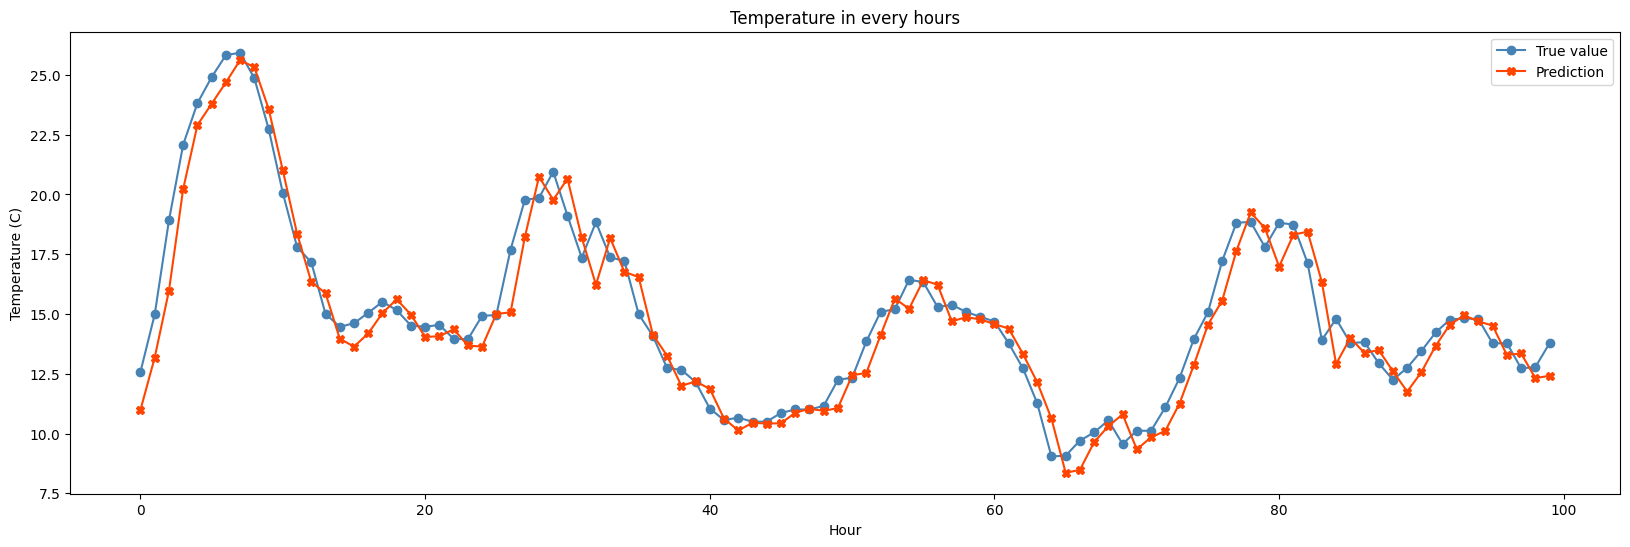

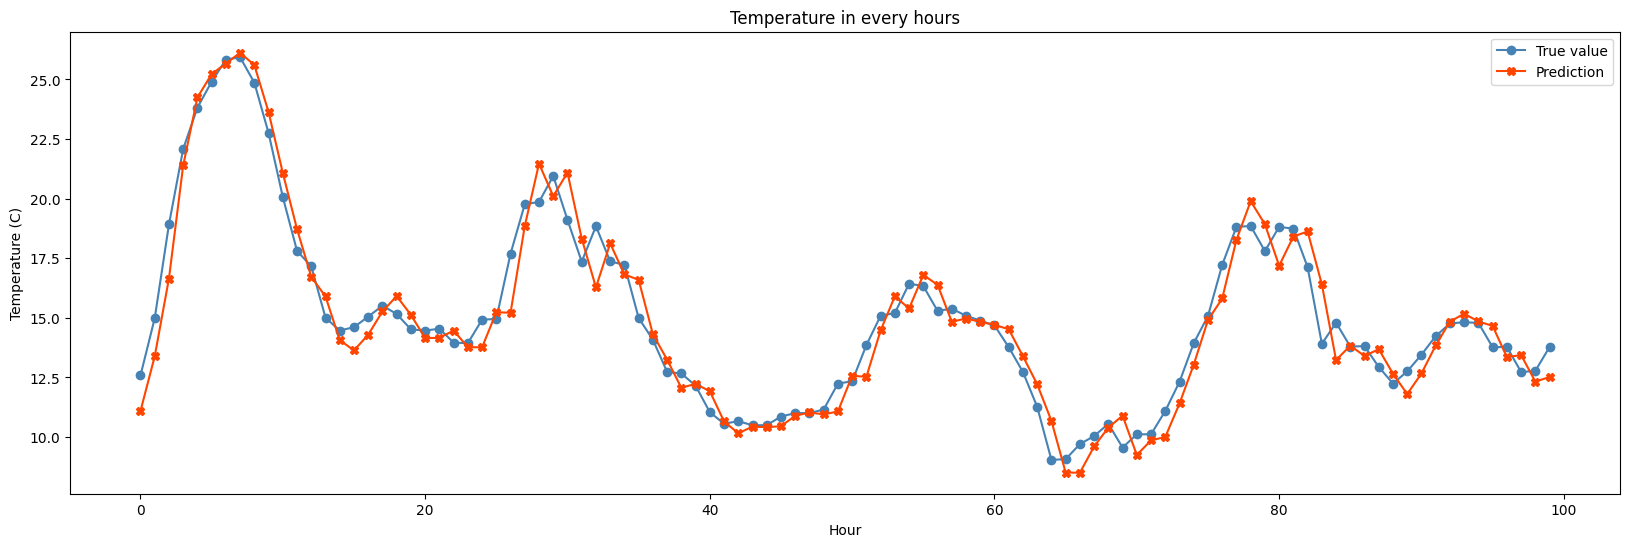

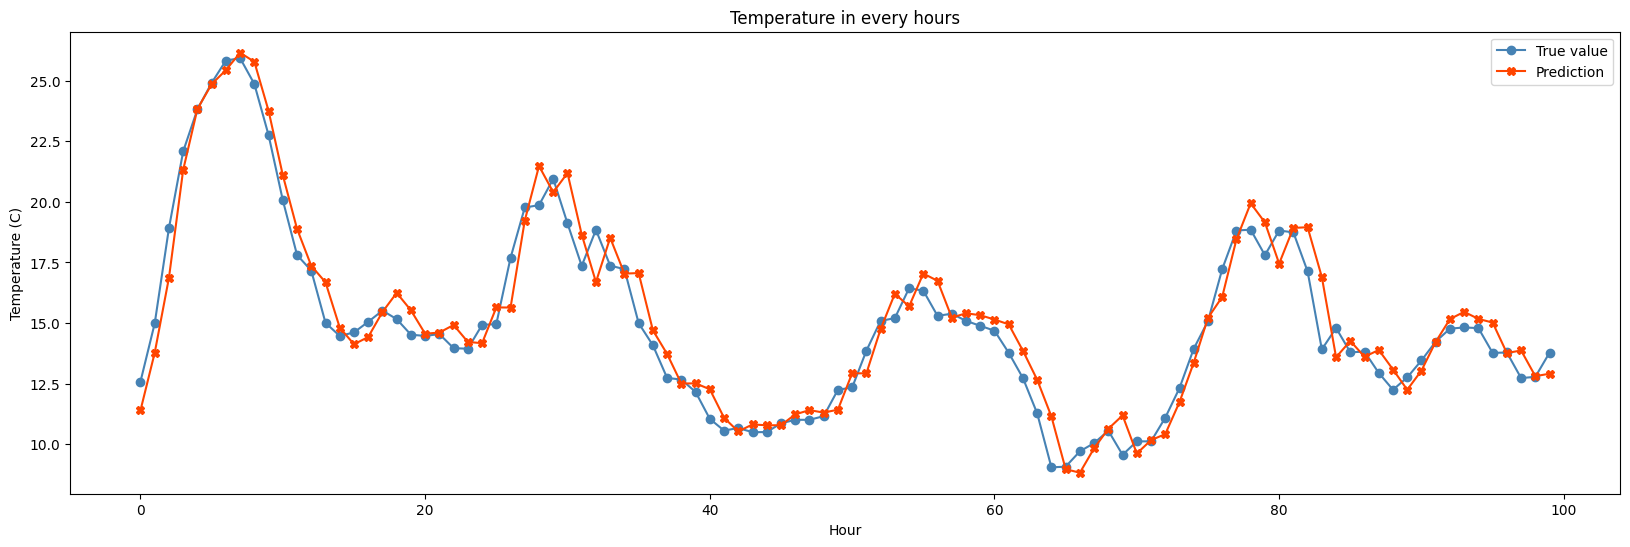

In [63]:
def plot_difference(y, pred):
    plt.figure(figsize=(20, 6))
    times = range(len(y))
    y_to_plot = y.flatten()
    pred_to_plot = pred.flatten()

    plt.plot(times, y_to_plot, color='steelblue', marker='o', label='True value')
    plt.plot(times, pred_to_plot, color='orangered', marker='X', label='Prediction')

    plt.title('Temperature in every hours')
    plt.xlabel('Hour')
    plt.ylabel('Temperature (C)')
    plt.legend()
    plt.show()

inputs = torch.tensor(X_test[:100], dtype=torch.float32).to(device)
model.eval()
model_lstm.eval()
model_bilstm.eval()
with torch.no_grad():
    outputs_rnn = model(inputs).detach().cpu().numpy()
    outputs_lstm = model_lstm(inputs).detach().cpu().numpy()
    outputs_bilstm = model_bilstm(inputs).detach().cpu().numpy()

plot_difference(y_test[:100], outputs_rnn)
plot_difference(y_test[:100], outputs_lstm)
plot_difference(y_test[:100], outputs_bilstm)